In [12]:
import zipfile

zip_path = "/content/images.zip"

extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Images Extracted Successfully")

Images Extracted Successfully


In [13]:
import os

dataset_path = "/content/images"

print(os.listdir(dataset_path))

['normal', '.DS_Store', 'scratch', 'dent', 'stain']


In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [15]:
classes = []

for item in os.listdir(dataset_path):

    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        classes.append(item)

print(classes)

for cls in classes:

    path = os.path.join(dataset_path, cls)

    print(
        cls,
        "->",
        len(os.listdir(path)),
        "images"
    )

['normal', 'scratch', 'dent', 'stain']
normal -> 120 images
scratch -> 120 images
dent -> 120 images
stain -> 120 images


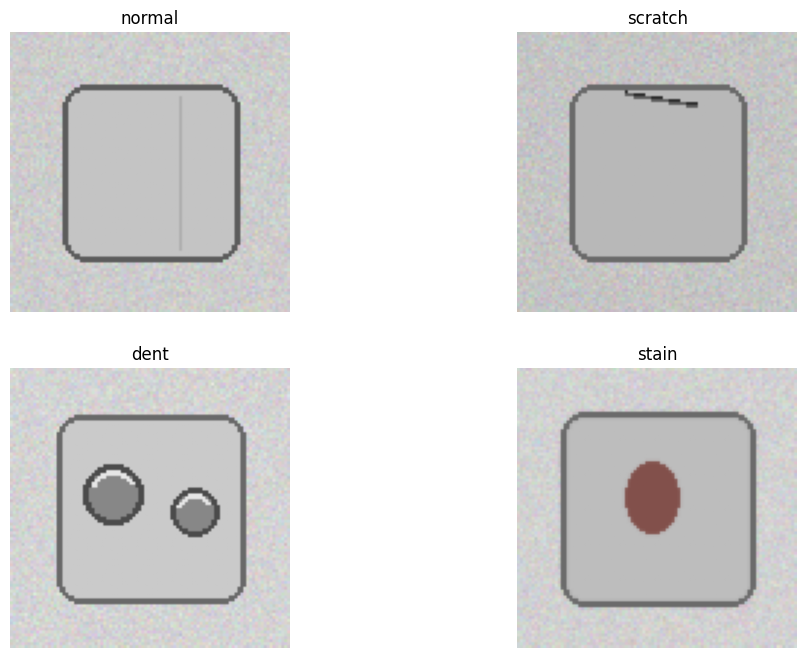

In [16]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    image = plt.imread(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")

plt.show()

# Problem Identification

This dataset represents an Image Classification problem.

Reason:
Each image belongs to one category:
- normal
- scratch
- dent
- stain

The CNN predicts the class label for each image.

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [18]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [19]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


In [20]:
model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# First Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Dropout Layer
model.add(
    Dropout(0.5)
)

# Output Layer
model.add(
    Dense(
        4,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 890ms/step - accuracy: 0.2760 - loss: 2.4833 - val_accuracy: 0.2500 - val_loss: 1.3815
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 922ms/step - accuracy: 0.3854 - loss: 1.3695 - val_accuracy: 0.2917 - val_loss: 1.3467
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 933ms/step - accuracy: 0.4479 - loss: 1.3259 - val_accuracy: 0.7083 - val_loss: 1.2689
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 928ms/step - accuracy: 0.5391 - loss: 1.2004 - val_accuracy: 0.5521 - val_loss: 1.1187
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5833 - loss: 1.0650 - val_accuracy: 0.5729 - val_loss: 0.9911
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.6302 - loss: 0.9334 - val_accuracy: 0.7188 - val_loss: 0.8081
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 814ms/step - accuracy: 0.7161 - loss: 0.8029 - val_accuracy: 0.7604 - val_loss: 0.6696
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 943ms/step - accuracy: 0.7656 - loss: 0.6398 - val_accurac

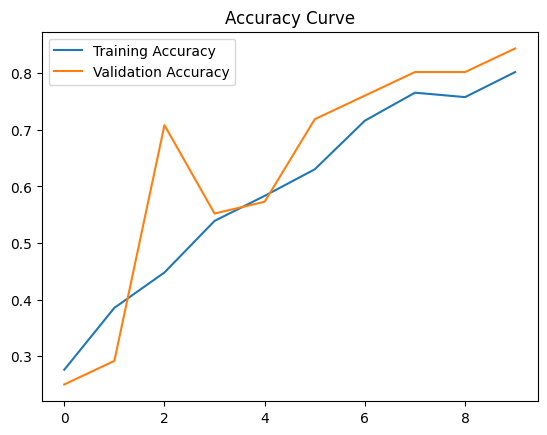

In [24]:
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title("Accuracy Curve")

plt.show()

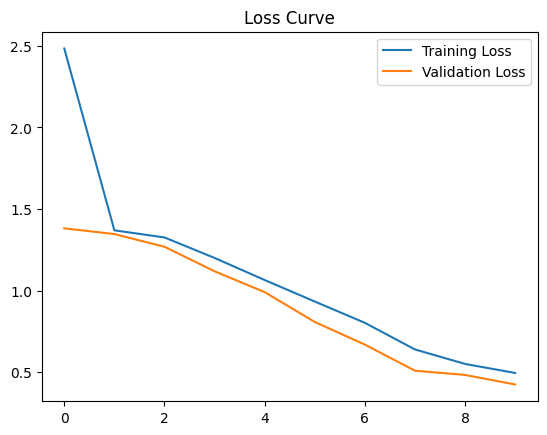

In [25]:
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title("Loss Curve")

plt.show()

In [26]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Validation Accuracy:", accuracy)

print("Validation Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.8333 - loss: 0.4380
Validation Accuracy: 0.8333333134651184
Validation Loss: 0.4380299150943756


In [27]:
predictions = model.predict(
    validation_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_generator.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step


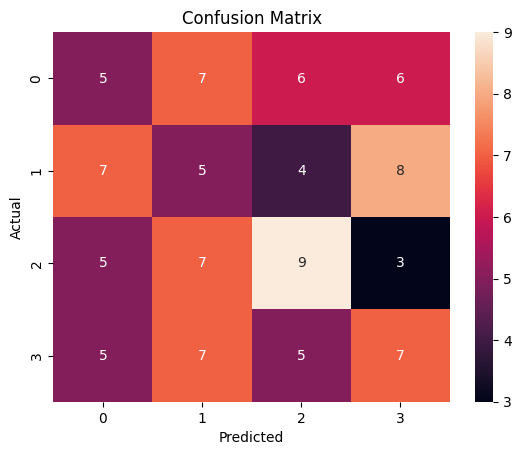

In [28]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
print(
    classification_report(
        true_classes,
        predicted_classes
    )
)

              precision    recall  f1-score   support

           0       0.23      0.21      0.22        24
           1       0.19      0.21      0.20        24
           2       0.38      0.38      0.38        24
           3       0.29      0.29      0.29        24

    accuracy                           0.27        96
   macro avg       0.27      0.27      0.27        96
weighted avg       0.27      0.27      0.27        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


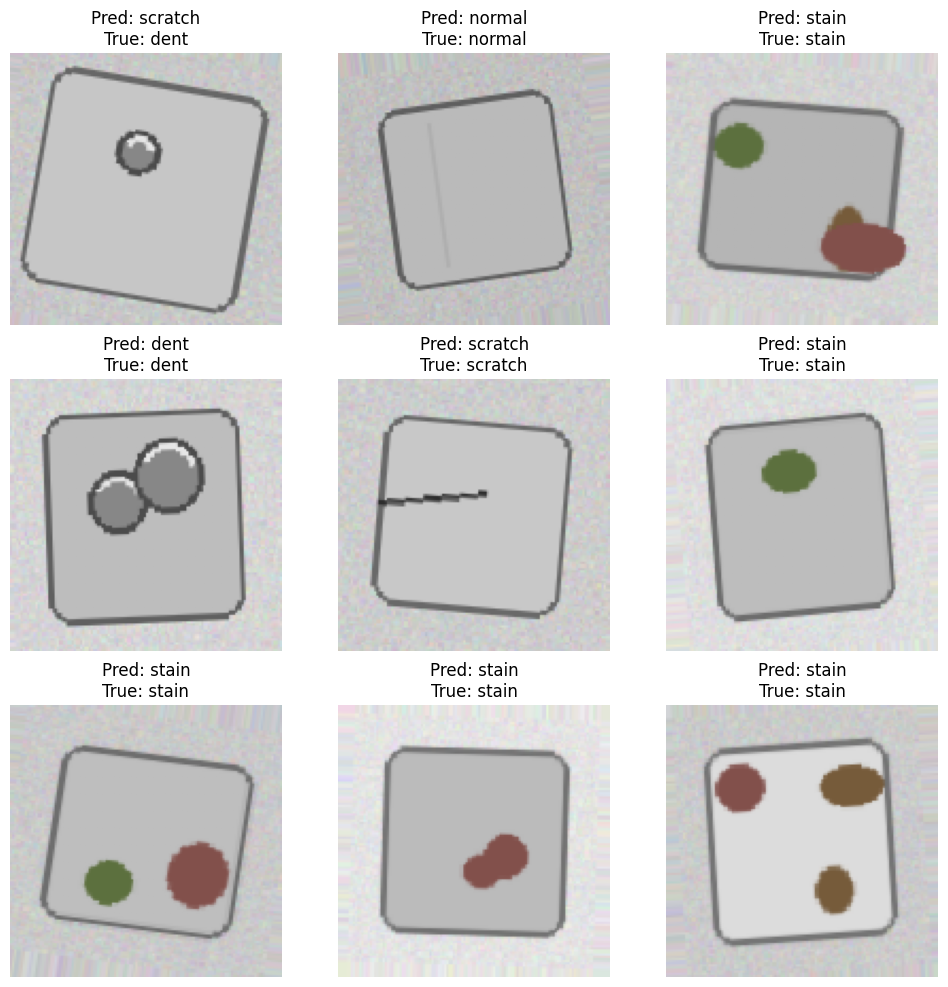

In [30]:
class_labels = list(
    validation_generator.class_indices.keys()
)

images, labels = next(validation_generator)

preds = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred_label = class_labels[
        np.argmax(preds[i])
    ]

    true_label = class_labels[
        np.argmax(labels[i])
    ]

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}"
    )

    plt.axis("off")

plt.show()

# CNN Concept Explanation

## What is Convolution?
Convolution helps identify patterns like edges and textures.

## Why is Pooling Used?
Pooling reduces image size and computation.

## Why is ReLU Used?
ReLU helps CNNs learn complex patterns efficiently.

## Why are CNNs Better for Images?
CNNs automatically learn visual patterns from image data.

# Business Use Case Mapping

This CNN model can be used in manufacturing quality inspection.

The system can automatically detect:
- scratches
- dents
- stains

Benefits:
- faster inspection
- reduced manual work
- improved product quality